# 서울 100m 격자별 65세 이상 인구 → 육각형 격자 변환

### 처리 단계
1. **65세 이상 격자 SHP 로드**: `서울_격자별_65세이상인구.shp`의 `val` 필드를 인구값으로 사용  
2. **서울 경계 정합성 확인**: `analysis_boundary_5181.shp` 기준으로 서울 내부 격자만 유지  
3. **정사각형 → 육각형 변환**: 100m 정사각 격자를 `analysis_grid_hex_clip.shp`의 육각형 셀로 공간 집계  
4. **출력**: `hex_population_65plus.csv` (GRID_ID 기준, 65세 이상 인구)

In [7]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")

BASE = Path(r"C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터")

# ── 경로 정의 ──────────────────────────────────────────────
PATH_ELDERLY_SHP = BASE / "인구_데이터" / "서울_격자별_65세이상인구.shp"
PATH_BOUNDARY    = BASE / "공간정보_데이터" / "서울_행정동_경계" / "analysis_boundary_5181.shp"
PATH_HEX         = BASE / "공간정보_데이터" / "100_grid" / "analysis_grid_hex_clip.shp"
PATH_OUT         = BASE / "인구_데이터" / "hex_population_65plus.shp"

TARGET_CRS = "EPSG:5179"

print("경로 확인:")
for name, p in [
    ("65세 이상 격자 SHP", PATH_ELDERLY_SHP),
    ("서울 경계", PATH_BOUNDARY),
    ("육각형 격자", PATH_HEX),
]:
    print(f"  {name}: {'OK' if p.exists() else '*** 없음 ***'} → {p}")
print(f"출력 파일: {PATH_OUT}")

경로 확인:
  65세 이상 격자 SHP: OK → C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터\인구_데이터\서울_격자별_65세이상인구.shp
  서울 경계: OK → C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터\공간정보_데이터\서울_행정동_경계\analysis_boundary_5181.shp
  육각형 격자: OK → C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터\공간정보_데이터\100_grid\analysis_grid_hex_clip.shp
출력 파일: C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터\인구_데이터\hex_population_65plus.shp


## STEP 1 · 65세 이상 100m 격자 SHP 로드 및 인구 컬럼 정리

In [2]:
elderly_gdf = gpd.read_file(PATH_ELDERLY_SHP).to_crs(TARGET_CRS)

# 원본 속성: gid(원본 격자 식별자), lbl(라벨), val(65세 이상 인구)
dasa_65 = elderly_gdf[["gid", "val", "geometry"]].copy()
dasa_65 = dasa_65.rename(columns={"gid": "source_grid_id", "val": "pop_65plus"})
dasa_65["pop_65plus"] = pd.to_numeric(dasa_65["pop_65plus"], errors="coerce").fillna(0).round().astype(int)

print(f"65세 이상 격자 로드 완료: {len(dasa_65):,}개")
print(f"총 65세 이상 인구 합계: {dasa_65['pop_65plus'].sum():,}명")
print(f"좌표계: {dasa_65.crs}")
dasa_65[["source_grid_id", "pop_65plus"]].head()

65세 이상 격자 로드 완료: 64,676개
총 65세 이상 인구 합계: 1,886,211명
좌표계: EPSG:5179


,source_grid_id,pop_65plus
0,다사598577,101
1,다사618570,51
2,다사599567,18
3,다사578564,133
4,다사608568,21


## STEP 2 · 서울 경계 정합성 확인 및 서울 내부 100m 격자만 유지

In [3]:
print(f"원본 65세 이상 격자 수: {len(dasa_65):,}개")

# ── 서울 경계 필터링 ────────────────────────────────────────
boundary_gdf = gpd.read_file(PATH_BOUNDARY)
boundary_5179 = boundary_gdf.to_crs(TARGET_CRS)
seoul_union = boundary_5179.geometry.union_all()

# 데이터명이 서울 기준이더라도 경계 기준으로 한 번 더 정합성 확인
working = dasa_65.copy()
working["centroid"] = working.geometry.centroid
within_seoul = working["centroid"].within(seoul_union)
dasa_seoul = working.loc[within_seoul].drop(columns=["centroid"]).reset_index(drop=True)

print(f"\n[서울 경계 필터링 결과]")
print(f"  서울 내 격자 수      : {len(dasa_seoul):,}개")
print(f"  서울 내 65+ 인구 합계: {dasa_seoul['pop_65plus'].sum():,}명")
print(f"  제외된 격자 수       : {(~within_seoul).sum():,}개")
dasa_seoul[["source_grid_id", "pop_65plus"]].head()

원본 65세 이상 격자 수: 64,676개

[서울 경계 필터링 결과]
  서울 내 격자 수      : 63,546개
  서울 내 65+ 인구 합계: 1,885,860명
  제외된 격자 수       : 1,130개


,source_grid_id,pop_65plus
0,다사598577,101
1,다사618570,51
2,다사599567,18
3,다사578564,133
4,다사608568,21


## STEP 3 · 정사각형 → 육각형 변환 (공간 집계: 100m 정사각 → hex GRID_ID)

In [4]:
# ── 육각형 격자 로드 (EPSG:5181 → 5179 변환) ───────────────
hex_gdf  = gpd.read_file(PATH_HEX)
hex_5179 = hex_gdf.to_crs(TARGET_CRS)
print(f"육각형 격자 수: {len(hex_5179):,}개 (CRS: {hex_5179.crs})")

# ── 100m 정사각 격자 중심점 → 육각형 셀 공간 조인 ─────────
dasa_pts = dasa_seoul.copy()
dasa_pts.geometry = dasa_pts.geometry.centroid

joined = gpd.sjoin(
    dasa_pts[["source_grid_id", "pop_65plus", "geometry"]],
    hex_5179[["GRID_ID", "geometry"]],
    how="inner",
    predicate="within",
)

# ── 육각형 단위로 65세 이상 인구 합산 ──────────────────────
hex_pop = (
    joined
    .groupby("GRID_ID", as_index=False)
    .agg(pop_65plus=("pop_65plus", "sum"))
)

hex_result = hex_5179[["GRID_ID"]].merge(hex_pop, on="GRID_ID", how="left")
hex_result["pop_65plus"] = hex_result["pop_65plus"].fillna(0).astype(int)

print(f"\n[정사각형 → 육각형 변환 결과]")
print(f"  전체 hex 수          : {len(hex_result):,}개")
print(f"  인구 있는 hex 수     : {(hex_result['pop_65plus'] > 0).sum():,}개")
print(f"  인구 없는 hex 수     : {(hex_result['pop_65plus'] == 0).sum():,}개")
print(f"  hex 총 65+ 인구      : {hex_result['pop_65plus'].sum():,}명")
print(f"  hex당 평균 인구(비0) : {hex_result.loc[hex_result['pop_65plus'] > 0, 'pop_65plus'].mean():.2f}명")
hex_result.head(10)

육각형 격자 수: 18,043개 (CRS: EPSG:5179)

[정사각형 → 육각형 변환 결과]
  전체 hex 수          : 18,043개
  인구 있는 hex 수     : 10,109개
  인구 없는 hex 수     : 7,934개
  hex 총 65+ 인구      : 1,885,860명
  hex당 평균 인구(비0) : 186.55명


,GRID_ID,pop_65plus
0,224,0
1,225,0
2,376,0
3,377,0
4,378,0
5,379,0
6,528,0
7,529,0
8,530,0
9,531,0


## STEP 4 · 결과 미리보기 및 간단한 지도 시각화

미리보기 컬럼: ['GRID_ID', 'geometry', 'pop_65plus']
미리보기 행 수: 18,043


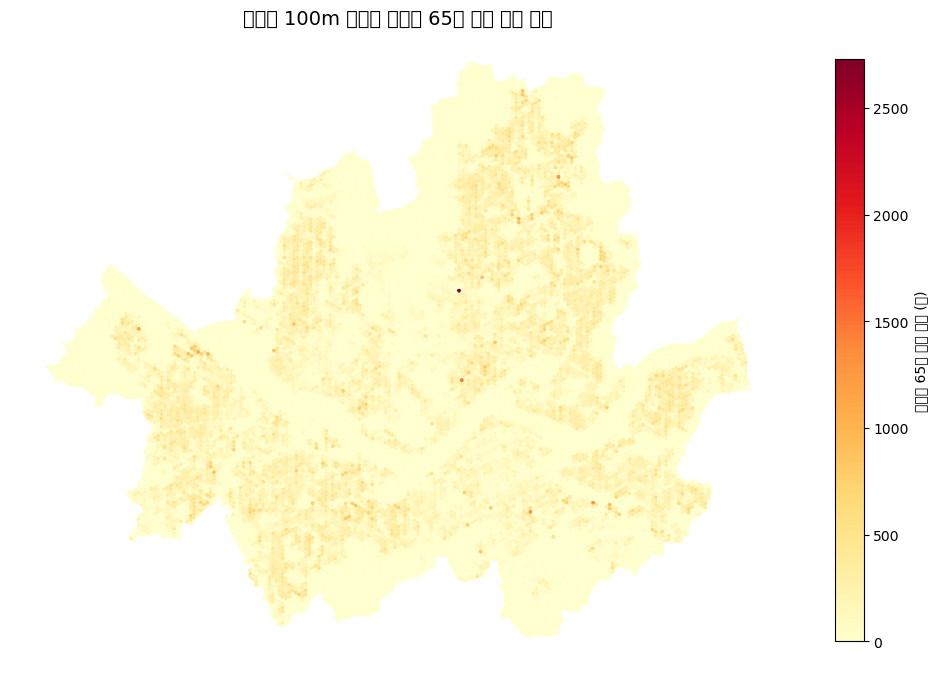

In [8]:
# ── 시각화용 geometry 결합 ──────────────────────────────────
import matplotlib.pyplot as plt

hex_geo = hex_5179[["GRID_ID", "geometry"]].merge(hex_result, on="GRID_ID", how="left")
hex_geo["pop_65plus"] = hex_geo["pop_65plus"].fillna(0).astype(int)

print(f"미리보기 컬럼: {hex_geo.columns.tolist()}")
print(f"미리보기 행 수: {len(hex_geo):,}")

fig, ax = plt.subplots(figsize=(10, 10), facecolor="white")
ax.set_facecolor("white")
hex_geo.plot(
    column="pop_65plus",
    cmap="YlOrRd",
    linewidth=0,
    ax=ax,
    legend=True,
    legend_kwds={"label": "격자별 65세 이상 인구 (명)", "shrink": 0.6},
)
ax.set_title("서울시 100m 육각형 격자별 65세 이상 인구 분포", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## STEP 5 · `hex_population.csv` 기준 GRID_ID 체계로 정렬 후 SHP 저장

`hex_result`는 STEP 3에서 공간 조인으로 생성되었지만, 최종 출력은 기존 `hex_population.csv`와 동일한 `GRID_ID` 체계를 유지하면서 geometry가 포함된 SHP 형식으로 저장합니다.
- `analysis_grid_hex_clip.shp`의 원본 `GRID_ID`와 geometry를 그대로 유지
- 누락 GRID_ID → `pop_65plus = 0` 으로 채움
- 최종 결과는 `hex_population_65plus.shp`로 저장

In [9]:
# ── analysis_grid_hex_clip GRID_ID + geometry 마스터 로드 ──────────────────
hex_master = gpd.read_file(PATH_HEX)[["GRID_ID", "geometry"]].copy()
hex_master["GRID_ID"] = hex_master["GRID_ID"].astype(int)
print(f"[analysis_grid_hex_clip] 전체 격자 수: {len(hex_master):,}개")
print(f"  원본 GRID_ID 범위: {hex_master['GRID_ID'].min()} ~ {hex_master['GRID_ID'].max()}")
print(f"  원본 좌표계      : {hex_master.crs}")

# ── 기존 hex_result와 GRID_ID 정합성 검증 ─────────────────────────────────
result_ids  = set(hex_result["GRID_ID"].astype(int))
master_ids  = set(hex_master["GRID_ID"])
only_master = master_ids - result_ids
only_result = result_ids - master_ids
print(f"\n[GRID_ID 정합성 검증]")
print(f"  analysis_grid_hex에만 있는 GRID_ID (누락): {len(only_master):,}개")
print(f"  hex_result에만 있는 GRID_ID  (불필요):     {len(only_result):,}개")

# ── hex_population.csv와 동일한 GRID_ID 체계 유지 + geometry 결합 ───────────
hex_out = hex_master.merge(
    hex_result[["GRID_ID", "pop_65plus"]].assign(GRID_ID=hex_result["GRID_ID"].astype(int)),
    on="GRID_ID",
    how="left",
)
hex_out["pop_65plus"] = hex_out["pop_65plus"].fillna(0).astype(int)
hex_out = gpd.GeoDataFrame(hex_out[["GRID_ID", "pop_65plus", "geometry"]], geometry="geometry", crs=hex_master.crs)

print(f"\n[최종 결과]")
print(f"  총 격자 수         : {len(hex_out):,}개")
print(f"  인구 있는 격자     : {(hex_out['pop_65plus'] > 0).sum():,}개")
print(f"  인구 없는 격자     : {(hex_out['pop_65plus'] == 0).sum():,}개")
print(f"  총 65+ 인구        : {hex_out['pop_65plus'].sum():,}명")
print(f"  GRID_ID 범위       : {hex_out['GRID_ID'].min()} ~ {hex_out['GRID_ID'].max()}")

# ── 최종 저장 (SHP 형식) ────────────────────────────────────────────────
hex_out.to_file(PATH_OUT, encoding="utf-8")
print(f"\n저장 완료: {PATH_OUT}")
print(f"컬럼: {hex_out.columns.tolist()}, 행수: {len(hex_out):,}")
hex_out.head(10)

[analysis_grid_hex_clip] 전체 격자 수: 18,043개
  원본 GRID_ID 범위: 224 ~ 32961
  원본 좌표계      : EPSG:5181

[GRID_ID 정합성 검증]
  analysis_grid_hex에만 있는 GRID_ID (누락): 0개
  hex_result에만 있는 GRID_ID  (불필요):     0개

[최종 결과]
  총 격자 수         : 18,043개
  인구 있는 격자     : 10,109개
  인구 없는 격자     : 7,934개
  총 65+ 인구        : 1,885,860명
  GRID_ID 범위       : 224 ~ 32961

저장 완료: C:\Users\THKIM\Desktop\4-1 프로젝트\서울시 빅데이터 캠퍼스 공모전\찐_데이터\인구_데이터\hex_population_65plus.shp
컬럼: ['GRID_ID', 'pop_65plus', 'geometry'], 행수: 18,043


,GRID_ID,pop_65plus,geometry
0,224,0,"POLYGON ((179362.967 450531.937, 179354.311 45..."
1,225,0,"POLYGON ((179362.967 450731.937, 179306.082 45..."
2,376,0,"POLYGON ((179478.437 450331.937, 179521.268 45..."
3,377,0,"MULTIPOLYGON (((179478.437 450531.937, 179536...."
4,378,0,"POLYGON ((179362.967 450731.937, 179478.437 45..."
5,379,0,"POLYGON ((179478.437 450731.937, 179362.967 45..."
6,528,0,"MULTIPOLYGON (((179709.377 450131.937, 179684...."
7,529,0,"POLYGON ((179478.437 450331.937, 179536.172 45..."
8,530,0,"POLYGON ((179651.642 450431.937, 179536.172 45..."
9,531,0,"POLYGON ((179651.642 450831.937, 179709.377 45..."
